In [34]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

Load and inspect the datasets

In [35]:
ts = pd.read_csv('https://raw.githubusercontent.com/5230066/assignments_files/refs/heads/main/lab7/malawi_retail_monthly_timeseries.csv')
ev = pd.read_csv('https://raw.githubusercontent.com/5230066/assignments_files/refs/heads/main/lab7/store_event_stream_sample.csv')

Preparing the time variables

In [36]:
ts['month'] = pd.to_datetime(ts['month'])
ts = ts.sort_values('month').reset_index(drop=True)

ev['event_time'] = pd.to_datetime(ev['event_time'])
ev = ev.sort_values('event_time').reset_index(drop=True)

Explore the monthly time series

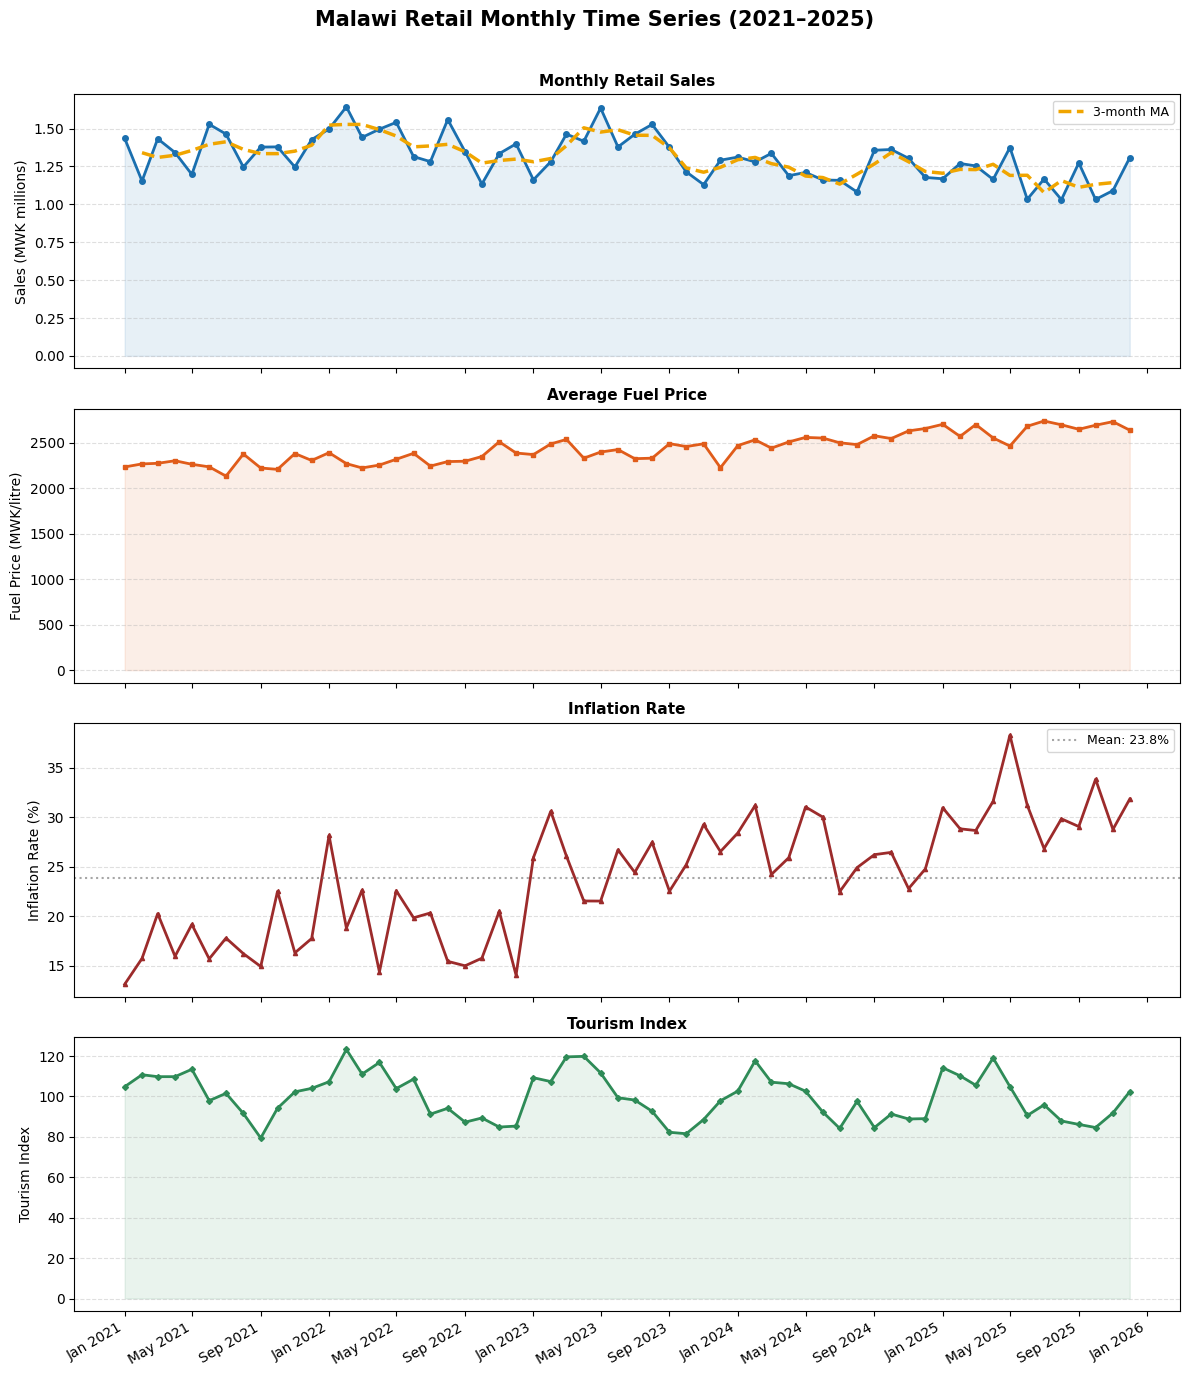

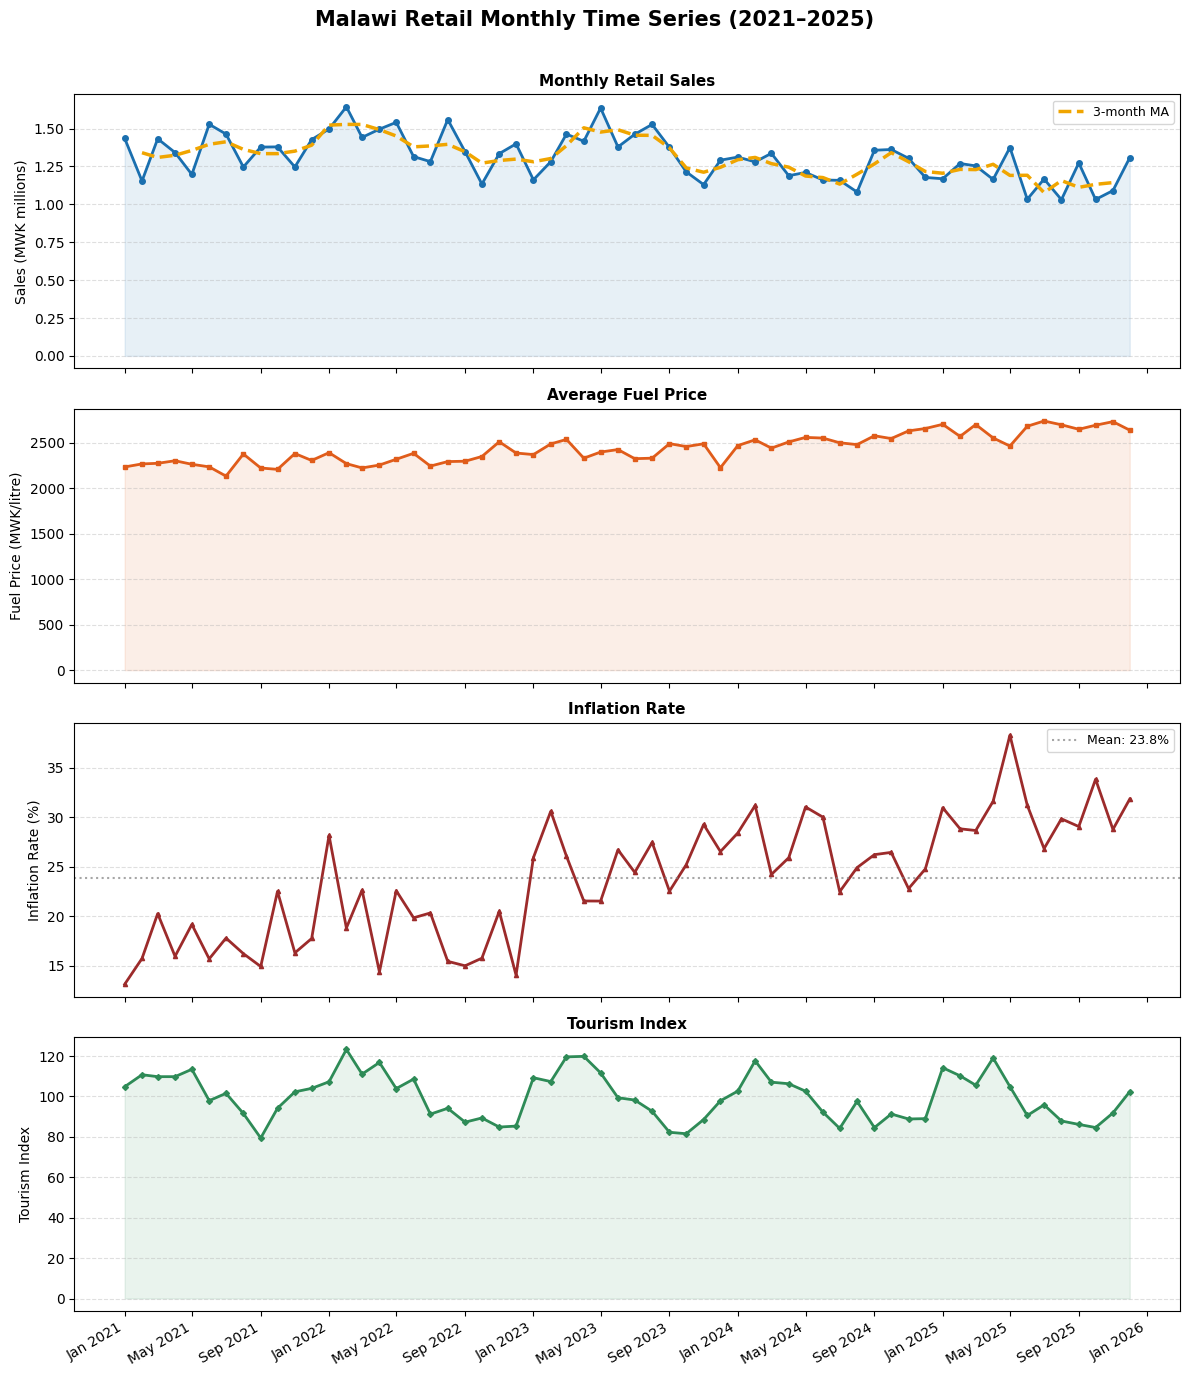

In [37]:
ts['sales_rolling3'] = ts['monthly_sales_mwk'].rolling(3, center=True).mean()

COLORS = {
    'sales': '#1a6faf',
    'fuel':  '#e05c1a',
    'inf':   '#9c2b2b',
    'tour':  '#2e8b57',
    'roll':  '#f0a500',
    'queue': '#7b2d8b',
    'trans': '#1a6faf',
    'alert': '#e05c1a',
}


fig1, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
fig1.suptitle('Malawi Retail Monthly Time Series (2021–2025)',
              fontsize=15, fontweight='bold', y=0.98)

ax = axes[0]
ax.plot(ts['month'], ts['monthly_sales_mwk']/1e6, color=COLORS['sales'], linewidth=2, marker='o', markersize=4)
ax.plot(ts['month'], ts['sales_rolling3']/1e6, color=COLORS['roll'], linewidth=2.5, linestyle='--', label='3-month MA')
ax.set_ylabel('Sales (MWK millions)', fontsize=10)
ax.set_title('Monthly Retail Sales', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.fill_between(ts['month'], ts['monthly_sales_mwk']/1e6, alpha=0.1, color=COLORS['sales'])
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
ax.plot(ts['month'], ts['avg_fuel_price_mwk'], color=COLORS['fuel'], linewidth=2, marker='s', markersize=3)
ax.set_ylabel('Fuel Price (MWK/litre)', fontsize=10)
ax.set_title('Average Fuel Price', fontsize=11, fontweight='bold')
ax.fill_between(ts['month'], ts['avg_fuel_price_mwk'], alpha=0.1, color=COLORS['fuel'])
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[2]
ax.plot(ts['month'], ts['inflation_rate_pct'], color=COLORS['inf'], linewidth=2, marker='^', markersize=3)
ax.set_ylabel('Inflation Rate (%)', fontsize=10)
ax.set_title('Inflation Rate', fontsize=11, fontweight='bold')
ax.axhline(ts['inflation_rate_pct'].mean(), color='gray', linestyle=':', alpha=0.7, label=f"Mean: {ts['inflation_rate_pct'].mean():.1f}%")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[3]
ax.plot(ts['month'], ts['tourism_index'], color=COLORS['tour'], linewidth=2, marker='D', markersize=3)
ax.set_ylabel('Tourism Index', fontsize=10)
ax.set_title('Tourism Index', fontsize=11, fontweight='bold')
ax.fill_between(ts['month'], ts['tourism_index'], alpha=0.1, color=COLORS['tour'])
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
display(fig1)

Text(0.5, 0.98, 'Seasonality & Year-over-Year Sales Analysis')

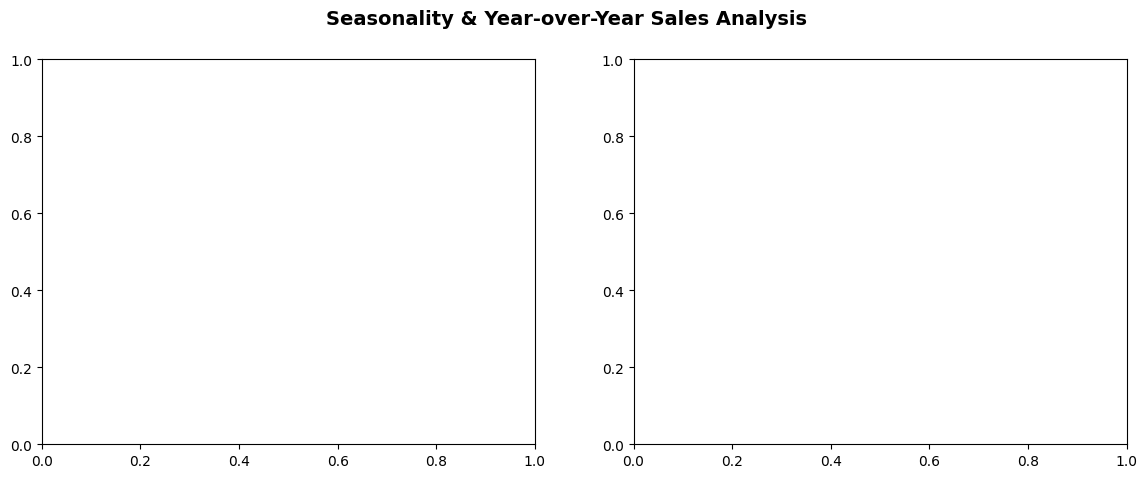

In [38]:
ts['month_num'] = ts['month'].dt.month
ts['year'] = ts['month'].dt.year
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Seasonality & Year-over-Year Sales Analysis', fontsize=14, fontweight='bold')


Analyze trend and seasonality, using  scatterplots, correlation analysis, or line comparisons


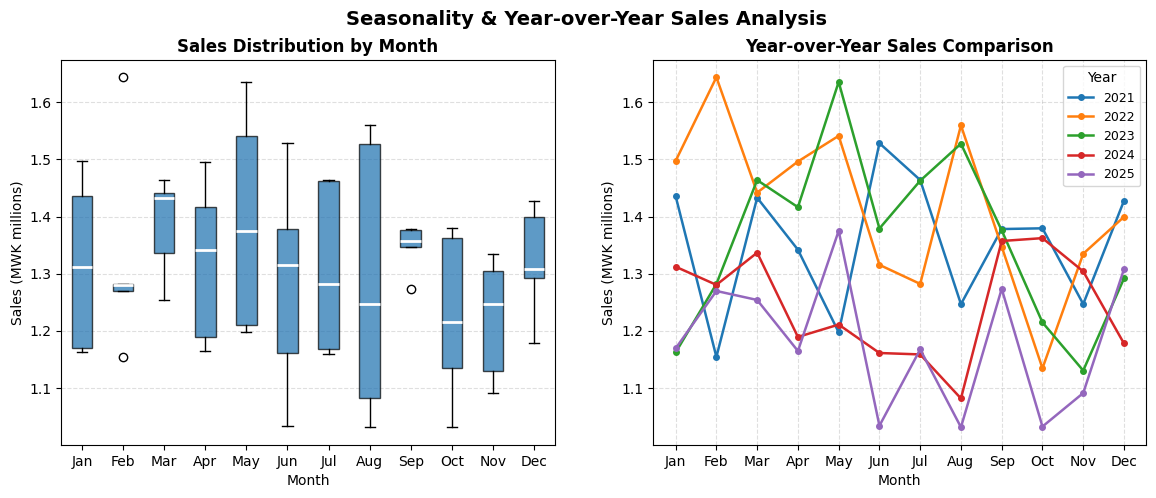

<Figure size 640x480 with 0 Axes>

In [39]:
monthly_grouped = [ts[ts['month_num']==m]['monthly_sales_mwk'].values/1e6 for m in range(1,13)]
bp = ax1.boxplot(monthly_grouped, labels=month_labels, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['sales'])
    patch.set_alpha(0.7)
ax1.set_title('Sales Distribution by Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sales (MWK millions)', fontsize=10)
ax1.set_xlabel('Month', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

for yr, grp in ts.groupby('year'):
    ax2.plot(grp['month_num'], grp['monthly_sales_mwk']/1e6,
             marker='o', markersize=4, label=str(yr), linewidth=1.8)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_labels)
ax2.set_title('Year-over-Year Sales Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sales (MWK millions)', fontsize=10)
ax2.set_xlabel('Month', fontsize=10)
ax2.legend(title='Year', fontsize=9)
ax2.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
display(fig2)

Examine relationships between variables

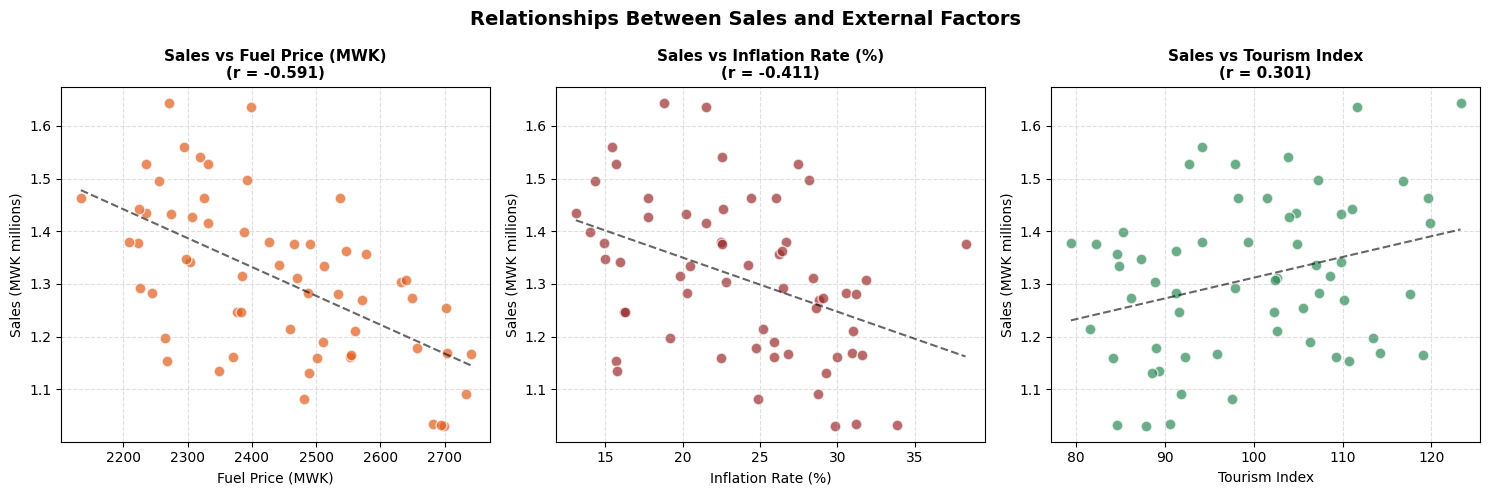

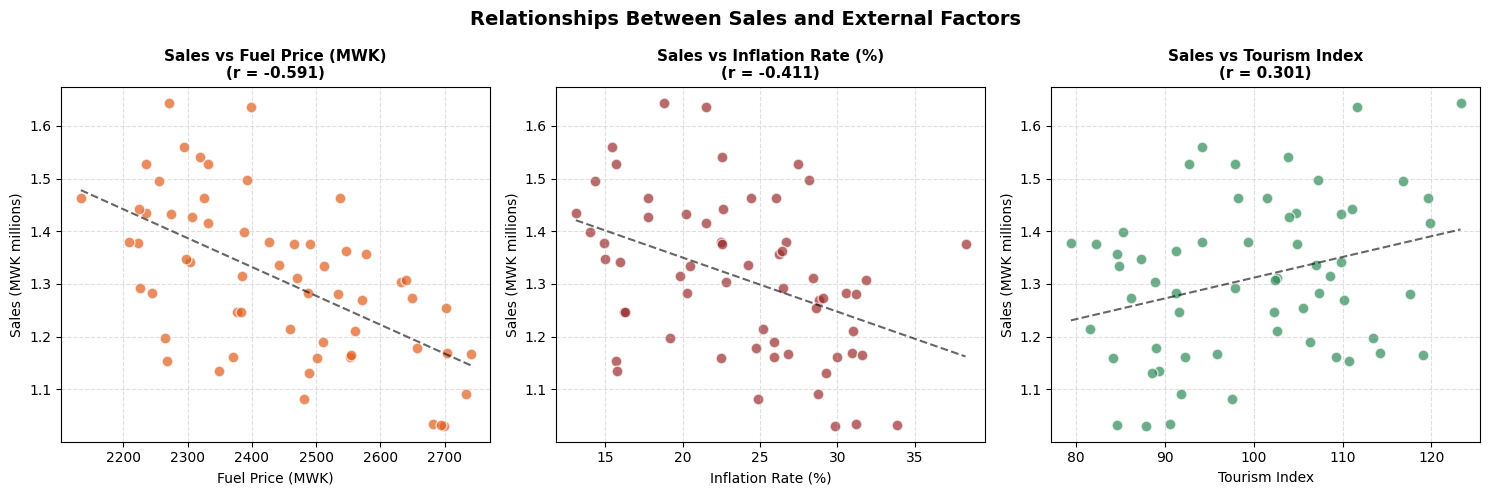

In [40]:
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle('Relationships Between Sales and External Factors', fontsize=14, fontweight='bold')

pairs = [
    ('avg_fuel_price_mwk', 'Fuel Price (MWK)', COLORS['fuel']),
    ('inflation_rate_pct', 'Inflation Rate (%)', COLORS['inf']),
    ('tourism_index',      'Tourism Index',     COLORS['tour']),
]

for ax, (col, xlabel, color) in zip(axes, pairs):
    r = ts[['monthly_sales_mwk', col]].corr().iloc[0,1]
    ax.scatter(ts[col], ts['monthly_sales_mwk']/1e6, color=color, alpha=0.7, edgecolors='white', s=60)
    # trend line
    m, b = np.polyfit(ts[col], ts['monthly_sales_mwk']/1e6, 1)
    xr = np.linspace(ts[col].min(), ts[col].max(), 100)
    ax.plot(xr, m*xr+b, 'k--', linewidth=1.5, alpha=0.6)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Sales (MWK millions)', fontsize=10)
    ax.set_title(f'Sales vs {xlabel}\n(r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
display(fig3)

Analyzing the event stream sample

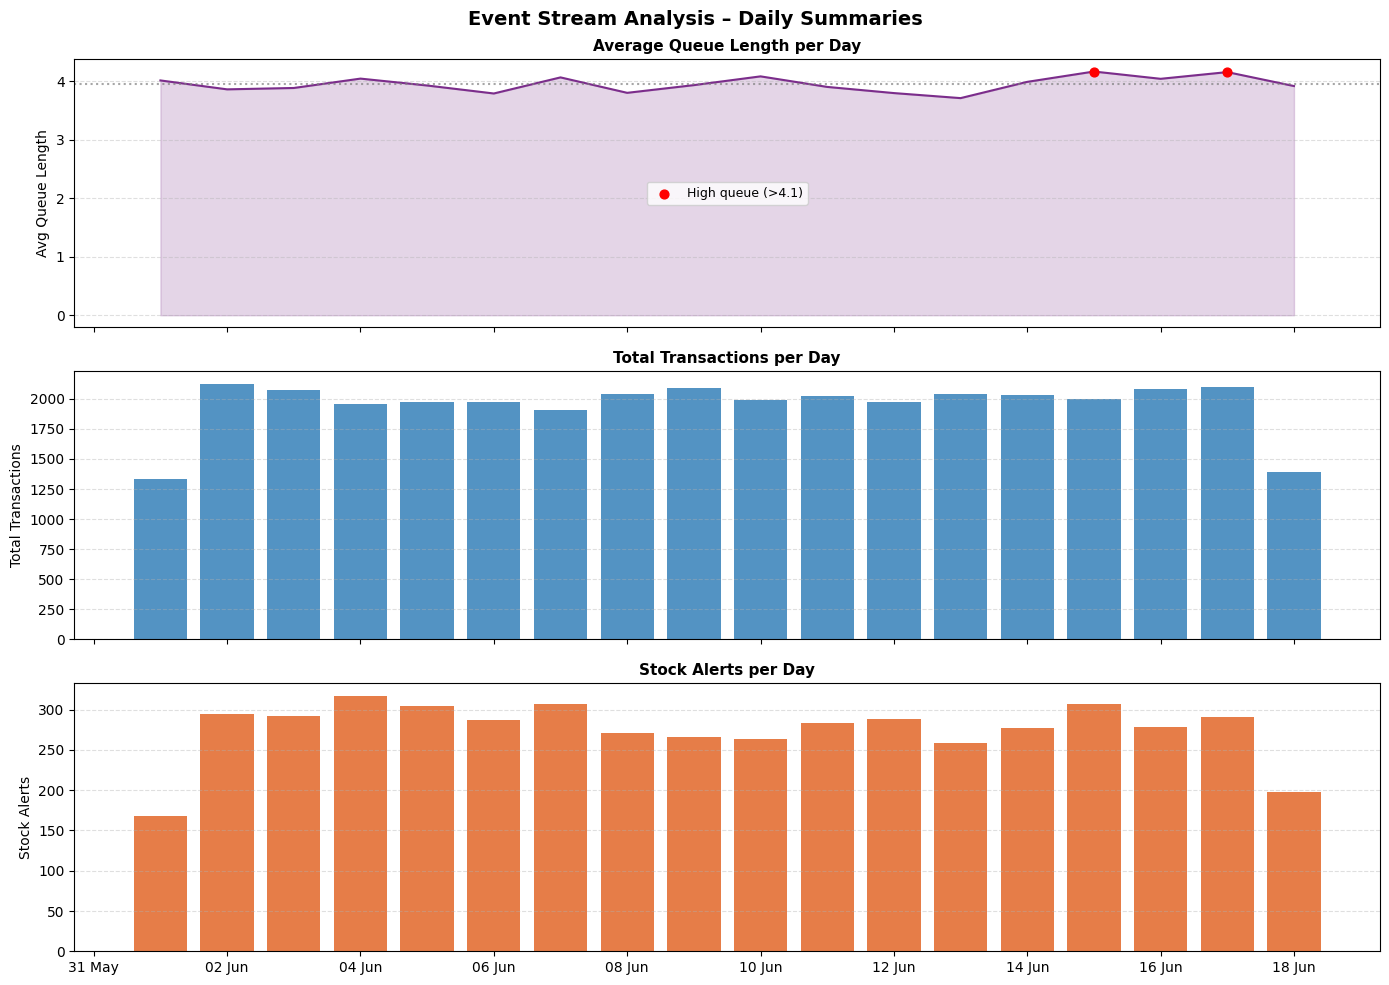

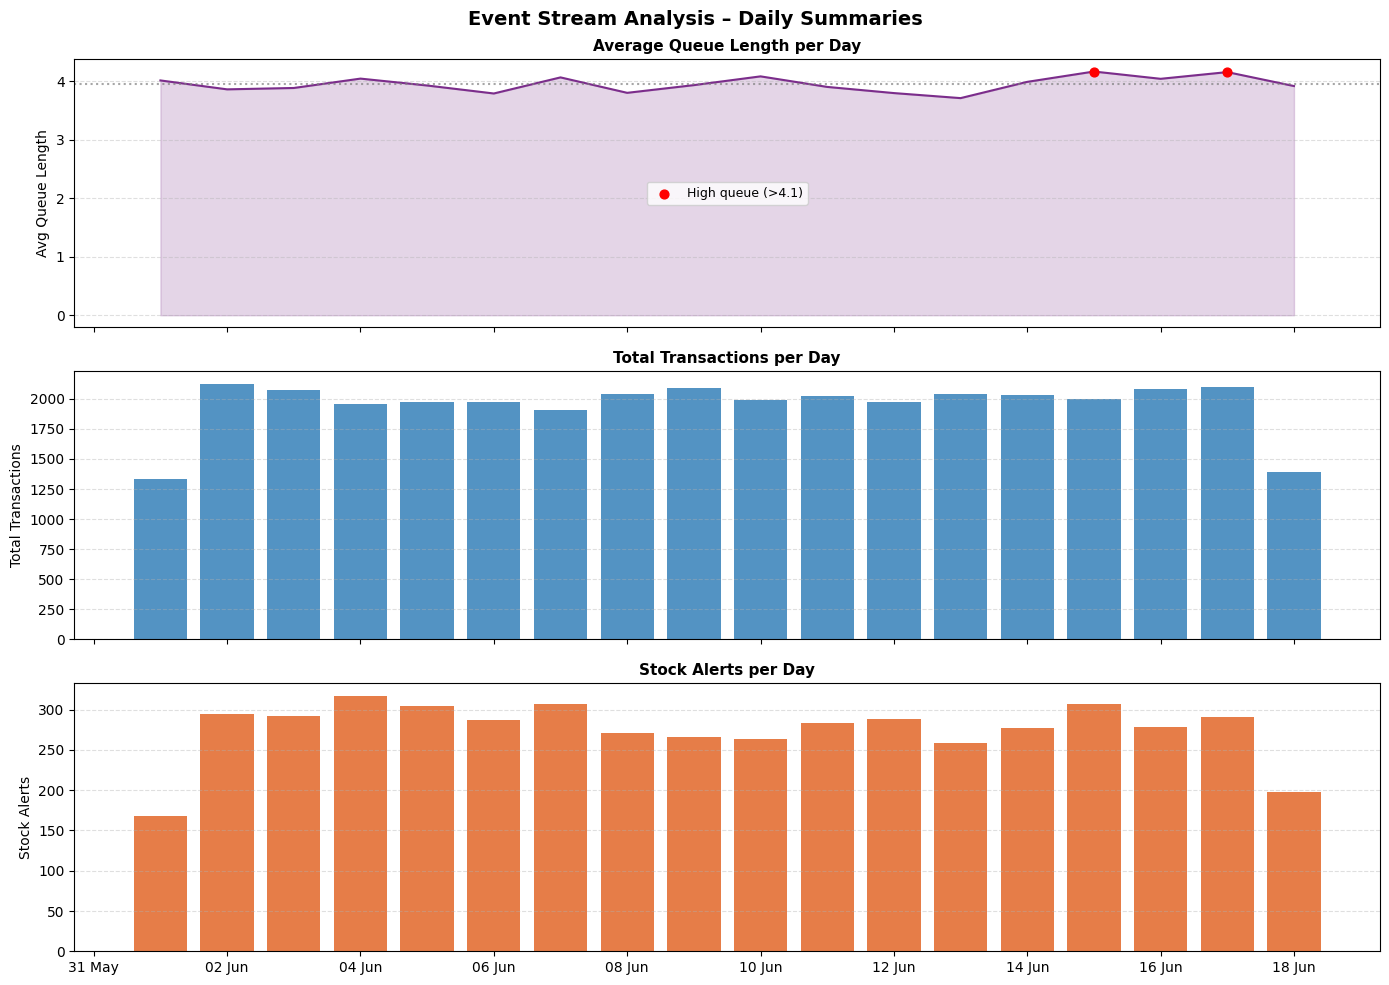

In [41]:
ev['day_bin'] = ev['event_time'].dt.floor('D')
hourly = ev.groupby('day_bin').agg(
    avg_queue=('queue_length','mean'),
    total_tx=('transactions_last_15min','sum'),
    total_alerts=('stock_alerts','sum'),
    event_count=('store_id','count')
).reset_index()

fig4, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig4.suptitle('Event Stream Analysis – Daily Summaries', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(hourly['day_bin'], hourly['avg_queue'], color=COLORS['queue'], linewidth=1.5)
ax.fill_between(hourly['day_bin'], hourly['avg_queue'], alpha=0.2, color=COLORS['queue'])
high_thresh = hourly['avg_queue'].mean() + hourly['avg_queue'].std()*1.5
peaks = hourly[hourly['avg_queue'] > high_thresh]
ax.scatter(peaks['day_bin'], peaks['avg_queue'], color='red', zorder=5, s=40, label=f'High queue (>{high_thresh:.1f})')
ax.axhline(hourly['avg_queue'].mean(), color='gray', linestyle=':', alpha=0.7)
ax.set_ylabel('Avg Queue Length', fontsize=10)
ax.set_title('Average Queue Length per Day', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
ax.bar(hourly['day_bin'], hourly['total_tx'], color=COLORS['trans'], alpha=0.75, width=0.8)
ax.set_ylabel('Total Transactions', fontsize=10)
ax.set_title('Total Transactions per Day', fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[2]
ax.bar(hourly['day_bin'], hourly['total_alerts'], color=COLORS['alert'], alpha=0.8, width=0.8)
ax.set_ylabel('Stock Alerts', fontsize=10)
ax.set_title('Stock Alerts per Day', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
display(fig4)

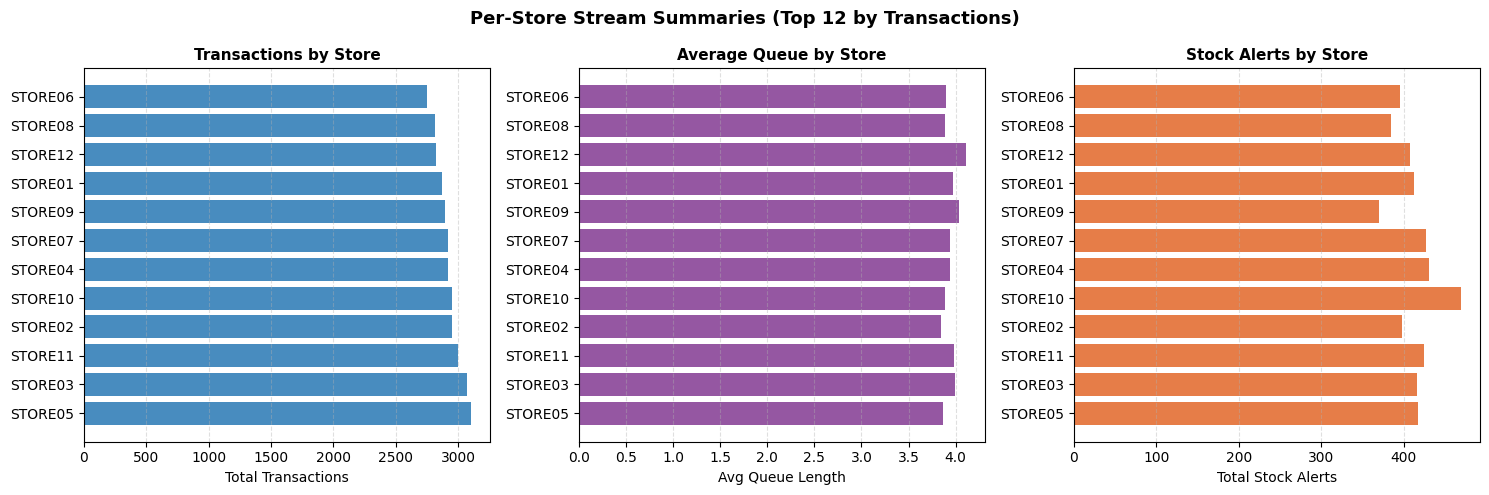

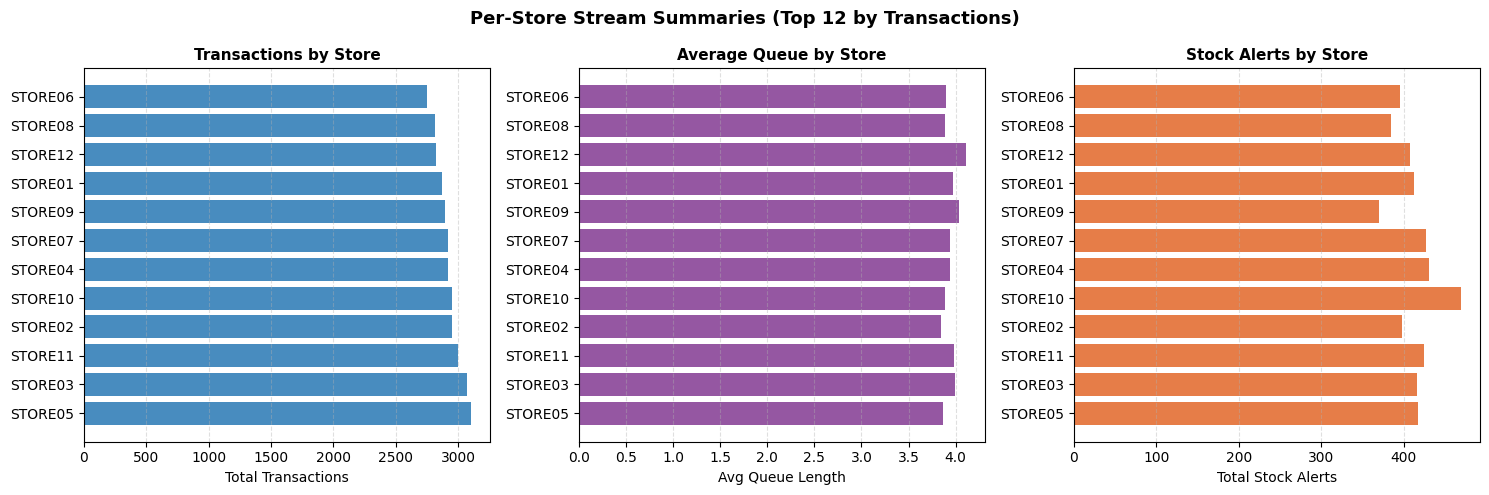

In [42]:
store_summary = ev.groupby('store_id').agg(
    avg_queue=('queue_length','mean'),
    total_tx=('transactions_last_15min','sum'),
    total_alerts=('stock_alerts','sum'),
    events=('event_time','count')
).reset_index().sort_values('total_tx', ascending=False).head(12)

fig5, axes = plt.subplots(1, 3, figsize=(15, 5))
fig5.suptitle('Per-Store Stream Summaries (Top 12 by Transactions)', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.barh(store_summary['store_id'], store_summary['total_tx'], color=COLORS['trans'], alpha=0.8)
ax.set_xlabel('Total Transactions', fontsize=10)
ax.set_title('Transactions by Store', fontsize=11, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax = axes[1]
ax.barh(store_summary['store_id'], store_summary['avg_queue'], color=COLORS['queue'], alpha=0.8)
ax.set_xlabel('Avg Queue Length', fontsize=10)
ax.set_title('Average Queue by Store', fontsize=11, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax = axes[2]
ax.barh(store_summary['store_id'], store_summary['total_alerts'], color=COLORS['alert'], alpha=0.8)
ax.set_xlabel('Total Stock Alerts', fontsize=10)
ax.set_title('Stock Alerts by Store', fontsize=11, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
display(fig5)

In [43]:
print("\n=== TIME SERIES STATS ===")
print(ts[['monthly_sales_mwk','avg_fuel_price_mwk','inflation_rate_pct','tourism_index']].describe().round(2))

print("\n=== CORRELATIONS WITH SALES ===")
for col in ['avg_fuel_price_mwk','inflation_rate_pct','tourism_index']:
    r = ts['monthly_sales_mwk'].corr(ts[col])
    print(f"  Sales vs {col}: r={r:.4f}")

print("\n=== STREAM STATS ===")
print(f"  Total events: {len(ev)}")
print(f"  Date range: {ev['event_time'].min()} to {ev['event_time'].max()}")
print(f"  Stores: {ev['store_id'].nunique()}")
print(f"  Max queue: {ev['queue_length'].max()} | Mean: {ev['queue_length'].mean():.2f}")
print(f"  Total stock alerts: {ev['stock_alerts'].sum()}")
print(f"  Hourly peak tx: {hourly['total_tx'].max()} at {hourly.loc[hourly['total_tx'].idxmax(),'day_bin']}")
print(f"  High-queue events (>mean+1.5sd): {len(peaks)}")


=== TIME SERIES STATS ===
       monthly_sales_mwk  avg_fuel_price_mwk  inflation_rate_pct  \
count              60.00               60.00               60.00   
mean          1311068.93             2438.72               23.80   
std            148999.94              160.55                5.96   
min           1031017.53             2134.04               13.11   
25%           1186223.34             2301.93               19.07   
50%           1309918.58             2434.08               24.60   
75%           1419132.82             2553.12               28.68   
max           1643887.93             2740.44               38.28   

       tourism_index  
count          60.00  
mean           99.80  
std            11.39  
min            79.43  
25%            90.27  
50%           100.45  
75%           108.77  
max           123.28  

=== CORRELATIONS WITH SALES ===
  Sales vs avg_fuel_price_mwk: r=-0.5907
  Sales vs inflation_rate_pct: r=-0.4114
  Sales vs tourism_index: r=0.3010

==

In [44]:
ev['hour_of_day'] = ev['event_time'].dt.hour
hod = ev.groupby('hour_of_day')['transactions_last_15min'].sum()
print(f"\n  Busiest hour of day: {hod.idxmax()}:00 ({hod.max()} transactions)")


  Busiest hour of day: 11:00 (1589 transactions)
